#### Land Cover Classification: SW Rwanda
**Author:** Marie Alice Uwingabire  
**Date:** 25th March 2026  
**Organization:** Oath Africa, Geospatial Analyst Assessment

#### Objective
Classify land use and land cover in SW Rwanda using Sentinel-2 
multispectral imagery and machine learning.

#### Pipeline
1. Data Loading & Exploration
2. Feature Engineering
3. Model Training & Cross Validation
4. Evaluation
5. Prediction & Visualization

#### Step 1: Importing all necessary python libraries

In [30]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

#### Step 2: Data Loading and Exploration

In [ ]:
# load training data
gdf = gpd.read_file("data/train_val.shp")
"""see what  shape, coordinates system, columns, and classes that exist"""
# see what shape exist
print(gdf.shape)
print(gdf.crs)
print(gdf.head())
# see what column exist
print(gdf.columns)
# see what classes exist
print(gdf["category"].value_counts())  

(800, 2)
EPSG:4326
  category                   geometry
0   forest  POINT (29.05868 -2.42512)
1      tea  POINT (29.06158 -2.42884)
2      tea  POINT (29.06205 -2.42944)
3      tea  POINT (29.06232 -2.43084)
4      tea  POINT (29.06508 -2.43202)
Index(['category', 'geometry'], dtype='object')
category
forest    200
tea       200
other     200
water     200
Name: count, dtype: int64


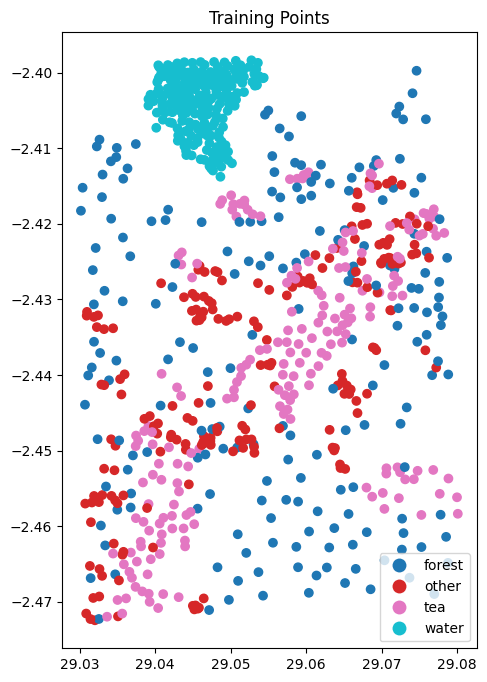

In [6]:
# plot the training data to get to know the data distribution
gdf.plot(column='category', legend=True, figsize=(10, 8))
plt.title("Training Points")
plt.show()

#### Step 1.1: Annotate data by using Qgis to add on buildup category after ecplore the annotated class

In [ ]:
# Load  buildup points and we will delete it to keep only clean points to avoid dataset inbalance
buildup = gpd.read_file("buildata/buildup_points_clean.shp")

# incase there is inconsistance in naming let's fix it
buildup['category'] = 'buildup'

# Keep only 200 random points
buildup = buildup.sample(n=200, random_state=42)
# check if there are only 200 samples
print(buildup['category'].value_counts())
print(buildup.shape)

# Save the cleaned version
buildup.to_file("buildup_points_clean.shp")

category
buildup    200
Name: count, dtype: int64
(200, 3)


#### Step 1.2: We merge the buildup class to the existing classes in tarain_val shapefile

In [11]:

# Merge
train_final = gpd.pd.concat([gdf, buildup[['category', 'geometry']]], ignore_index=True)

print(train_final['category'].value_counts())
print(train_final.shape)  

# Save
train_final.to_file("training_final.shp")

category
forest     200
tea        200
other      200
water      200
buildup    200
Name: count, dtype: int64
(1000, 2)


#### Step 1.3 : Now load the final merged training data as your gdf


CRS: EPSG:4326


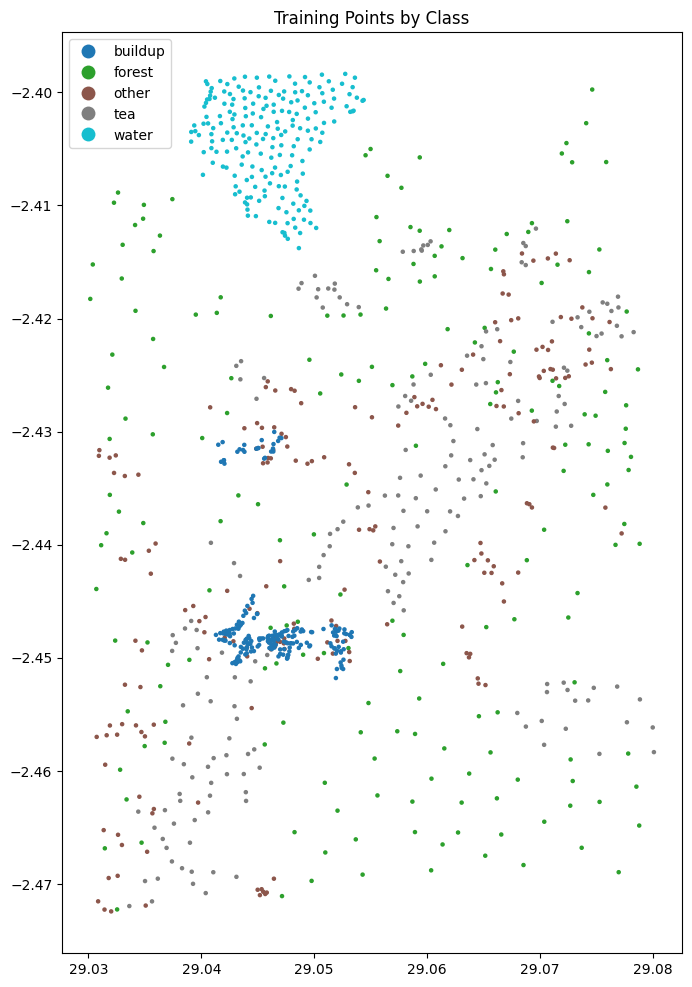

In [17]:
# Load training data
gdf = gpd.read_file("finaldata/training_final.shp")
# check its coordinate system
print("\nCRS:", gdf.crs)

# Plot the final training data to learn how where the point are
fig, ax = plt.subplots(figsize=(8, 12))
gdf.plot(column='category', legend=True, ax=ax, markersize=5)
ax.set_title("Training Points by Class")
plt.show()



#### Step 1.4: Load sentinel 2 Imagery and read key bands

In [23]:
# load sentinel 2 Imagery
with rasterio.open("finaldata/S2_srw.tif") as src:
    print("CRS:", src.crs)
    print("Number of bands:", src.count)
    print("Image size:", src.width, "x", src.height)
    print("band description:", src.descriptions)
    # Read key bands for classification and index computation
    """Bands are in reverse order"""
    b2 = src.read(11).astype(np.float32)  # Blue
    b3 = src.read(10).astype(np.float32)  # Green
    b4 = src.read(9).astype(np.float32)  # Red
    b8 = src.read(5).astype(np.float32)  # NIR which is key for vegetation
    b11 = src.read(2).astype(np.float32)  # shortwave infrared
    
    # Save metadata for output raster creation later
    meta = src.meta.copy()
    transform = src.transform
    crs = src.crs



CRS: EPSG:4326
Number of bands: 11
Image size: 654 x 881
band description: ('B12', 'B11', 'B10', 'B9', 'B8', 'B7', 'B6', 'B5', 'B4', 'B3', 'B2')


#### Step 2: Feature Engineering
We extract spectral band values at each training point location 
and compute the following indices:

- **NDVI** (Normalized Difference Vegetation Index), distinguishes 
  vegetation (forest, tea) from non-vegetation (buildup, other). 
  Range: -1 to 1, healthy vegetation > 0.3. Formula: (NIR - Red) / (NIR + Red)

- **NDWI** (Normalized Difference Water Index), highlights water bodies 
  by exploiting the strong water absorption in NIR. 
  Range: -1 to 1, water > 0. Formula: (Green - NIR) / (Green + NIR)

- **NDBI** (Normalized Difference Built-up Index), separates built-up 
  areas from vegetation using SWIR (B11). Built-up areas reflect SWIR 
  strongly while vegetation absorbs it. Formula: (SWIR - NIR) / (SWIR + NIR)

- **SAVI** (Soil Adjusted Vegetation Index), improves on NDVI for sparse 
  vegetation like tea plantations by reducing soil background noise. 
  Particularly useful for distinguishing tea from forest. 
  Formula: 1.5 * (NIR - Red) / (NIR + Red + 0.5)

- **BSI** (Bare Soil Index), identifies bare soil and other non-vegetated 
  non-built-up areas using a combination of SWIR, Red, NIR and Blue bands. 
  Helps separate the 'other' class from vegetation and buildup.
  Formula: ((Red + SWIR) - (NIR + Blue)) / ((Red + SWIR) + (NIR + Blue))

In [ ]:
with rasterio.open("finaldata/S2_srw.tif") as src:
    """ reproject gdf's \coordinate referance system to the one of sentinel-2 imegery as for further analysis crs for both have to match"""
    gdf_proj = gdf.to_crs(src.crs)
    # extract coordinates from gdf's geometry
    coords = [(geom.x, geom.y) for geom in gdf_proj.geometry]
    band_values = np.array(list(src.sample(coords))).astype(np.float32)

# Extract bands at training points and follow the reverse ordering from sentinel2 imegery
red   = band_values[:, 8]   
nir   = band_values[:, 4]   
green = band_values[:, 9]   
blue  = band_values[:, 10]  
swir  = band_values[:, 1]   

#  compute NDVI, NDWI, NDBI, SAVI, and BSI then add small value almost zero at denominator to handle divison by zero
ndvi_pts = (nir - red) / (nir + red + 1e-10)

ndwi_pts = (green - nir) / (green + nir + 1e-10)

ndbi_pts = (swir - nir) / (swir + nir + 1e-10)

savi_pts = 1.5 * (nir - red) / (nir + red + 0.5 + 1e-10)

bsi_pts = ((red + swir) - (nir + blue)) / ((red + swir) + (nir + blue) + 1e-10)

# Compute same indices for entire image (this will be used in final prediction)
# handle divison by zero
np.seterr(divide='ignore', invalid='ignore') 
ndvi = (b8 - b4) / (b8 + b4)
ndwi = (b3 - b8) / (b3 + b8)
ndbi = (b11 - b8) / (b11 + b8)
savi = 1.5 * (b8 - b4) / (b8 + b4 + 0.5)
bsi  = ((b4 + b11) - (b8 + b2)) / ((b4 + b11) + (b8 + b2))

# Build feature matrix by using all bands + all indices
X = np.column_stack([band_values, ndvi_pts, ndwi_pts, ndbi_pts, savi_pts, bsi_pts])

# Encode labels
le = LabelEncoder()
y = le.fit_transform(gdf_proj["category"].values)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", le.classes_)

Feature matrix shape: (1000, 16)
Labels shape: (1000,)
Classes: ['buildup' 'forest' 'other' 'tea' 'water']


#### Step 3: Model Training and Cross validation

We use Random Forest Classifier which is an ensemble of decision trees well 
suited for land cover classification because:
- Handles multiclass problems natively
- Robust to noisy training data
- Works well with mixed feature types (bands + indices)

We use 5-fold cross validation for reliable accuracy estimation, 
then evaluate on a held-out 20% validation set.

In [26]:
"""
test_size=0.2  means 80% training, 20% validation
stratify, ensures equal class distribution in both splits 

"""
# split training and testing data
X_train, X_val, y_train, y_val = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)
# check training and validation shape
print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

# 5-fold cross validation
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\nCV Accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

# Train final model on training set
rf.fit(X_train, y_train)

# Evaluate on held-out validation set
y_pred = rf.predict(X_val)
print("\nClassification Report:")
# print classification report
print(classification_report(y_val, y_pred, target_names=le.classes_))

Train size: (800, 16)
Val size: (200, 16)

CV Accuracy: 0.802 +/- 0.044

Classification Report:
              precision    recall  f1-score   support

     buildup       0.71      0.72      0.72        40
      forest       0.95      0.90      0.92        40
       other       0.54      0.62      0.58        40
         tea       0.83      0.72      0.77        40
       water       1.00      1.00      1.00        40

    accuracy                           0.80       200
   macro avg       0.81      0.80      0.80       200
weighted avg       0.81      0.80      0.80       200



#### Step 4: Evaluation

#### step 4.1: Conclusion from classification report (Result Interpretation)

The model achieves **80% overall accuracy** with a cross-validation score of 
**0.802 ± 0.044**, showing stable performance across folds. Water and Forest 
are classified near-perfectly (F1 = 1.00 and 0.92) due to their distinct 
spectral signatures. Tea and Buildup show moderate performance as both share 
spectral similarities with neighboring classes. The weakest class is Other 
(F1 = 0.58) which I think was expected since it is a broad catch-all category with highly 
variable spectral signatures, which  I see as a labeling challenge rather than a 
model limitation.

#### Step 4.2: plot confusion matrix

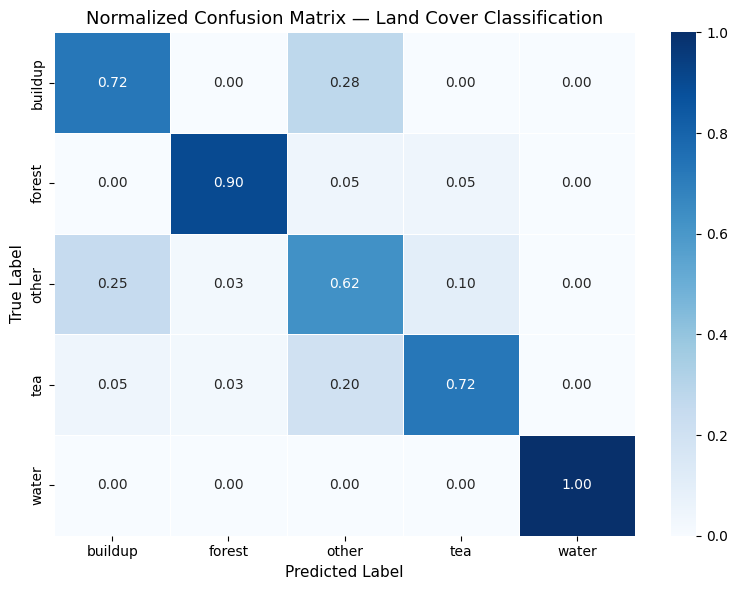

In [ ]:
import seaborn as sns

# Normalized confusion matrix
cm = confusion_matrix(y_val, y_pred)
cm_normalized = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
# plot the confusion matrix 
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_normalized,annot=True, fmt=".2f", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.5,linecolor="white")
ax.set_title("Normalized Confusion Matrix, Land Cover Classification", fontsize=13)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

#### Step 5: Prediction and Visualization
We apply the trained Random Forest model to every pixel in the Sentinel-2 
image to produce a complete land cover map of SW Rwanda. The image is 
reshaped from (bands, height, width) to (pixels, features) for prediction, 
then reshaped back to (height, width) for visualization. The same features 
used during training all 11 bands plus 5 indices are applied here in 
the exact same order to ensure consistent predictions.

In [ ]:
# Read all 11 bands for prediction
with rasterio.open("finaldata/S2_srw.tif") as src: 
    all_bands = src.read().astype(np.float32)  

# Compute indices for entire image 
np.seterr(divide='ignore', invalid='ignore')
ndvi = (b8 - b4) / (b8 + b4)
ndwi = (b3 - b8) / (b3 + b8)
ndbi = (b11 - b8) / (b11 + b8)
savi = 1.5 * (b8 - b4) / (b8 + b4 + 0.5)
bsi  = ((b4 + b11) - (b8 + b2)) / ((b4 + b11) + (b8 + b2))

# Stack all bands + indices (order must be as one for training otherwise our prediction will be wrong)
image_features = np.vstack([all_bands,ndvi[np.newaxis],ndwi[np.newaxis],ndbi[np.newaxis],savi[np.newaxis], bsi[np.newaxis]])  

# we have to reshape for prediction 
n_features, height, width = image_features.shape
X_image = image_features.reshape(n_features, -1).T
# check the shape to help with debugging  in case error rises
print("Image feature shape:", X_image.shape)  

# Predict on the entire the entire area of interest
predictions = rf.predict(X_image)
predictions = predictions.reshape(height, width)
print("Prediction shape:", predictions.shape)
print("Unique classes predicted:", np.unique(predictions))

Image feature shape: (576174, 16)
Prediction shape: (881, 654)
Unique classes predicted: [0 1 2 3 4]


#### Step 5.1: Visualize the landcover map
We visualize the predicted land cover map assigning a distinct color to 
each of the 5 classes. The map gives a spatial overview of land use 
distribution across the study area in SW Rwanda.

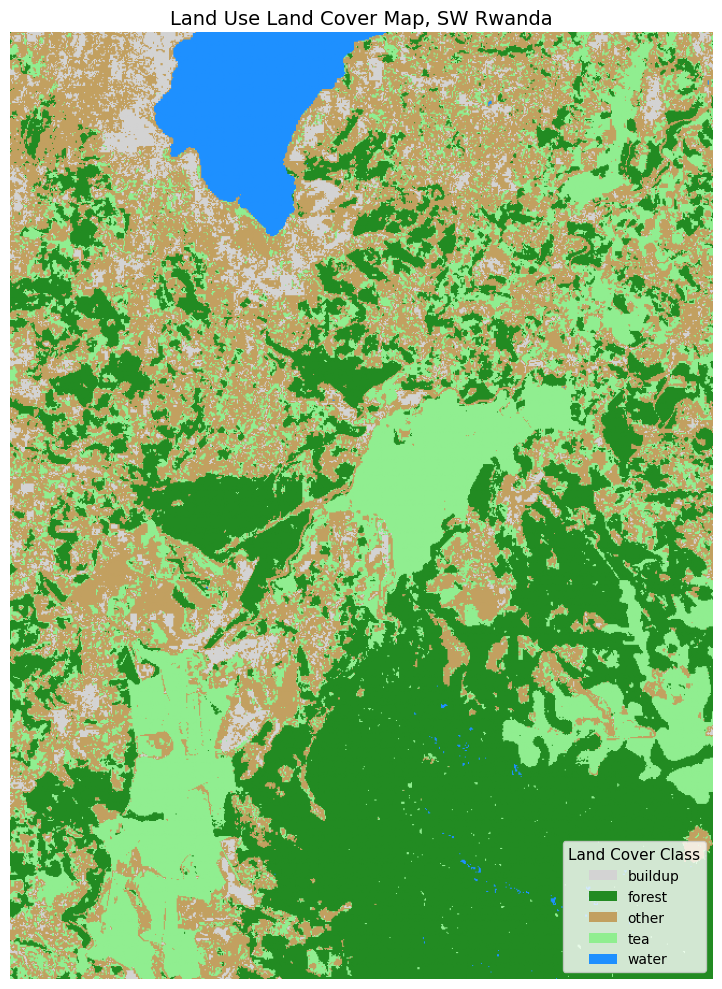

In [32]:
# Colors matching real-world appearance of each class
"""Order must match lebal encoding classes  [buildup, forest, other, tea, water]"""

colors = ["#D3D3D3", "#228B22", "#C2A060", "#90EE90", "#1E90FF"]

cmap = ListedColormap(colors)
# initialize figure
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(predictions, cmap=cmap, vmin=0, vmax=len(le.classes_)-1)

# Add legend
legend_elements = [Patch(facecolor=colors[i], label=le.classes_[i])
                   for i in range(len(le.classes_))]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10, 
          title="Land Cover Class", title_fontsize=11)
# customize figure elements
ax.set_title("Land Use Land Cover Map, SW Rwanda", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("lulc_map.png", dpi=300, bbox_inches="tight")
plt.show()

#### Conclusion


The land cover map reveals a landscape dominated by tea plantations 
and forest cover, consistent with SW Rwanda's agricultural and 
conservation profile. water is clearly visible in the northwest 
and is perfectly classified which must correspond to lake kivu and dense forest patches could probably be 
Nyungwe Forest National Park as its in south west. additionally, tea plantations dominate the hillsides 
while buildup is scattered across small settlements throughout the region.

#### Step 6: Save prediction as GeoTiff

In [34]:
# copy meta to keep the original and avoid overwritting
out_meta = meta.copy()
out_meta.update({"count": 1, "dtype": "int32"})
# save prediction raster
with rasterio.open("output/land_cover.tif", "w", **out_meta) as dst:
    dst.write(predictions.astype("int32"), 1)

print("Land cover map saved successfully!")

Land cover map saved successfully!
